In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Parquet dosyasını parça parça oku
parquet_file = pq.ParquetFile('../data/transactions_clean.parquet')

aylik_dict = {}
kategori_dict = {}
client_dict = {}

print("Veri okunuyor...")

for i, batch in enumerate(parquet_file.iter_batches(batch_size=500_000)):
    chunk = batch.to_pandas()
    
    gider = chunk[chunk['transaction_type'] == 'Gider']
    
    # Aylık harcama
    for (y, m), grp in gider.groupby(['year', 'month']):
        key = f"{y}-{str(m).zfill(2)}"
        aylik_dict[key] = aylik_dict.get(key, 0) + grp['abs_amount'].sum()
    
    # Kategori harcama
    for kat, grp in gider.groupby('kategori'):
        kategori_dict[kat] = kategori_dict.get(kat, 0) + grp['abs_amount'].sum()
    
    # Client özeti
    for cid, grp in chunk.groupby('client_id'):
        if cid not in client_dict:
            client_dict[cid] = {'toplam': 0, 'islem': 0, 'hata': 0}
        client_dict[cid]['toplam'] += grp['abs_amount'].sum()
        client_dict[cid]['islem'] += len(grp)
        client_dict[cid]['hata'] += (grp['errors'] != 'No Error').sum()
    
    print(f"  Parça {i+1} tamamlandı ({(i+1)*500_000:,} satır işlendi)")

print("✅ Tüm veri işlendi!")

# DataFrame'e çevir
aylik_df = pd.DataFrame(list(aylik_dict.items()), columns=['dönem','toplam']).sort_values('dönem')
kategori_df = pd.DataFrame(list(kategori_dict.items()), columns=['kategori','toplam']).sort_values('toplam', ascending=False)
client_df = pd.DataFrame([{'client_id': k, **v} for k, v in client_dict.items()])

print(f"Aylık dönem sayısı: {len(aylik_df)}")
print(f"Kategori sayısı: {len(kategori_df)}")
print(f"Client sayısı: {len(client_df)}")

Veri okunuyor...
  Parça 1 tamamlandı (500,000 satır işlendi)
  Parça 2 tamamlandı (1,000,000 satır işlendi)
  Parça 3 tamamlandı (1,500,000 satır işlendi)
  Parça 4 tamamlandı (2,000,000 satır işlendi)
  Parça 5 tamamlandı (2,500,000 satır işlendi)
  Parça 6 tamamlandı (3,000,000 satır işlendi)
  Parça 7 tamamlandı (3,500,000 satır işlendi)
  Parça 8 tamamlandı (4,000,000 satır işlendi)
  Parça 9 tamamlandı (4,500,000 satır işlendi)
  Parça 10 tamamlandı (5,000,000 satır işlendi)
  Parça 11 tamamlandı (5,500,000 satır işlendi)
  Parça 12 tamamlandı (6,000,000 satır işlendi)
  Parça 13 tamamlandı (6,500,000 satır işlendi)
  Parça 14 tamamlandı (7,000,000 satır işlendi)
  Parça 15 tamamlandı (7,500,000 satır işlendi)
  Parça 16 tamamlandı (8,000,000 satır işlendi)
  Parça 17 tamamlandı (8,500,000 satır işlendi)
  Parça 18 tamamlandı (9,000,000 satır işlendi)
  Parça 19 tamamlandı (9,500,000 satır işlendi)
  Parça 20 tamamlandı (10,000,000 satır işlendi)
  Parça 21 tamamlandı (10,500,000

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])

CompletedProcess(args=['c:\\financeai\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'matplotlib', 'seaborn'], returncode=0)

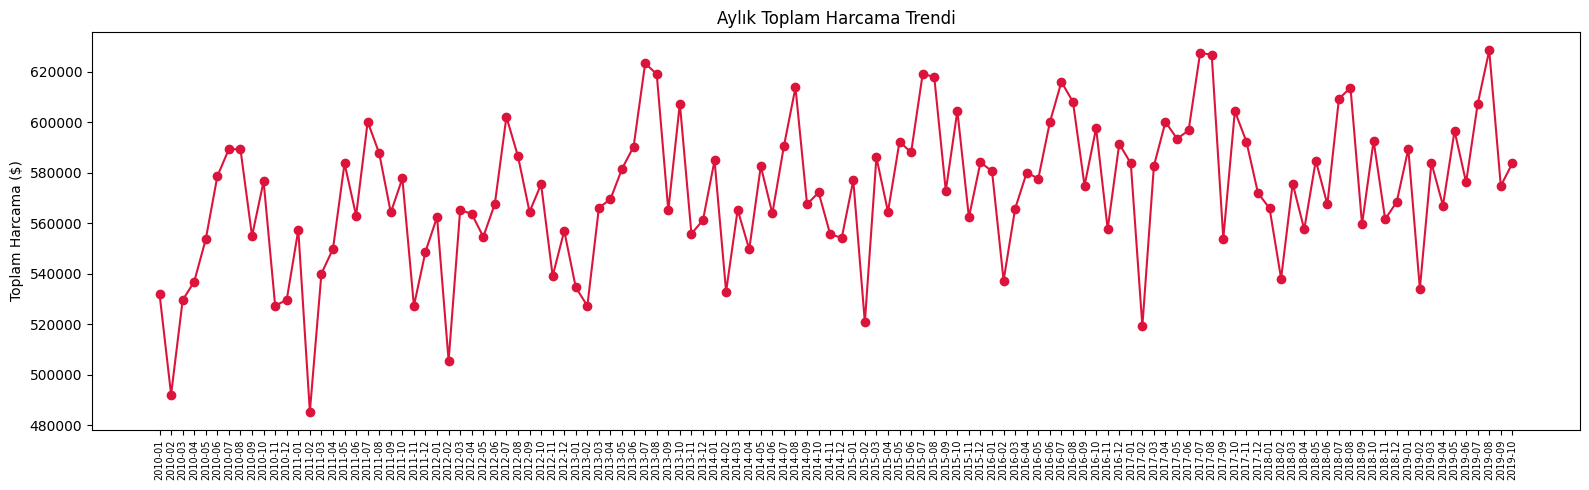

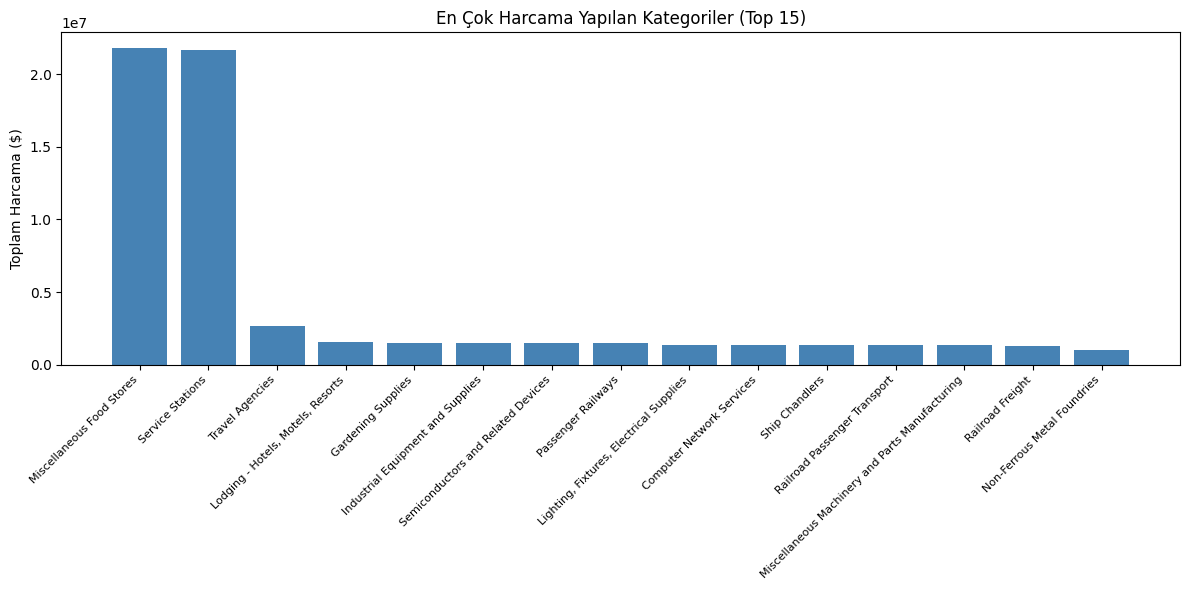

✅ Grafikler ve client özeti kaydedildi!
         client_id        toplam         islem         hata
count  1219.000000  1.219000e+03   1219.000000  1219.000000
mean   1004.916325  5.798799e+05  10915.434783   173.415094
std     582.384462  3.593401e+05   5607.355367   153.993608
min       0.000000  3.690134e+04    760.000000     7.000000
25%     496.500000  3.574020e+05   7223.500000    99.000000
50%    1019.000000  4.927860e+05   9832.000000   137.000000
75%    1514.500000  7.201575e+05  13349.000000   202.000000
max    1998.000000  3.558461e+06  48479.000000  2935.000000


In [3]:
import matplotlib.pyplot as plt

# 1. AYLIK HARCAMA TRENDİ
plt.figure(figsize=(16, 5))
plt.plot(aylik_df['dönem'], aylik_df['toplam'], marker='o', linewidth=1.5, color='crimson')
plt.xticks(rotation=90, fontsize=7)
plt.title('Aylık Toplam Harcama Trendi')
plt.ylabel('Toplam Harcama ($)')
plt.tight_layout()
plt.savefig('../outputs/aylik_trend.png', dpi=150)
plt.show()

# 2. KATEGORİ BAZLI HARCAMA
plt.figure(figsize=(12, 6))
top15 = kategori_df.head(15)
plt.bar(top15['kategori'], top15['toplam'], color='steelblue')
plt.title('En Çok Harcama Yapılan Kategoriler (Top 15)')
plt.ylabel('Toplam Harcama ($)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/kategori_harcama.png', dpi=150)
plt.show()

# 3. CLIENT ÖZETİ KAYDET
client_df.to_csv('../data/client_ozet.csv', index=False)
print("✅ Grafikler ve client özeti kaydedildi!")
print(client_df.describe())